# Testing DMA for I/Q Data Extraction
Attempting some different ideas in this file, feel free to look through and perform changes.

To start, I want to investigate what rfsoc_sam actually exposes/uses in creating the analyzer. 

In [3]:
from rfsoc_sam.overlay import Overlay
import numpy as np

sam = Overlay()

# Navigate to spectrum analyzer
channel = sam.radio.receiver.channels[0]
sa = channel.spectrum_analyser

# Enable auto DMA
sa.dma_enable = 1

Matplotlib is building the font cache; this may take a moment.


Grab a frame

In [6]:
frame = sa.get_frame()
print(frame.shape)
print(frame.min())
print(frame.max())
print(frame[:10]) # first 10 vals

(2048,)
-136.59138
-80.543884
[ -93.30327  -103.54386  -101.85783  -109.798584  -99.5679   -100.08564
 -104.85299  -103.30616   -95.258026  -96.41361 ]


-90 to -105 dBFS is thus the noisefloor... I have some thoughts on why this is (not that it matters) but could be handy to look into quantization error from bits for the report


----

Save/transfer to HOST PC

In [9]:
np.save('/home/xilinx/jupyter_notebooks/JACOBS_FILES/Data/Frame', frame)

frame is a 2048-point array of power spectrum values in dBFS (decibels relative to full scale). Each element corresponds to a frequency bin from the FFT. A 'snapshot' of what the SA is displaying on the screen at a given moment. 

RFSoC uses the following data path

RF ADC (Real sig) --> DDC (Mixes to baseband) --> SSR Converter (Serialiser) --> FFT (2048 points) --> Spectrum processor --> Auto DMA (Writes float32 array to mem buff) --> frame

From ADC to Auto DMA is all on PL (And thus nothing can be changed!!) the only way to change this section (incl. sampling rate) is to generate a new bitstream.

----

# Trying another PL Configuration
Strath Uni have also developed a QPSK tx/rx and visualiser. The bitstream used in this project has a DMA buffer connected to the I/Q samples directly which we could "borrow" to get I/Q samples off the board...

In [1]:
from rfsoc_qpsk.qpsk_overlay import QpskOverlay
import numpy as np

qpsk = QpskOverlay()

They also have a mem buffer which can be used to configure the DAC/ADCs on the fly by way of this crazy 'xrfdc' module

In [20]:
import xrfdc

mixer_cfg = qpsk.adc_block.MixerSettings
mixer_cfg['Freq'] = 1090 #MHz
qpsk.adc_block.MixerSettings = mixer_cfg
qpsk.adc_block.UpdateEvent(xrfdc.EVENT_MIXER)

print("ADC Tuned to 1090 MHZ :D!")

ADC Tuned to 1090 MHZ :D!


Now to capture raw I/Q data from the spectrum (single capture --> 128 samples)

In [4]:
frameIQ = qpsk.qpsk_rx.get_decimated()
print(frameIQ.shape)
print(frameIQ.dtype)
print(frameIQ[:5]) # First five samples

(128,)
complex128
[-38.-41.j -31.-41.j -42.-38.j -36.-37.j -41.-41.j]


As a note --> looking in the code i think the fs is 1024MSPS. 

ADS-B at 1090Mhz uses PPM at 1Mbit/s, PW = 0.5 us, Preamble = 8ms, Short squitter 56b = 64 us (incl. preamble), long squitter 112b = 120 us total (incl. preamble).

In [6]:
print(qpsk.adc_block.BlockStatus)
print(qpsk.adc_block.DecimationFactor)

{'SamplingFreq': 1.024, 'AnalogDataPathStatus': 1, 'DigitalDataPathStatus': 897, 'DataPathClocksStatus': 1, 'IsFIFOFlagsEnabled': 3, 'IsFIFOFlagsAsserted': 0}
8


Confirmed fs, decimation factor is 8,

so output_rate = 1024MSPS / 8 = 128 MSPS --> so at 128 samples per frame, roughly 64-120 frames are required to capture a full message. (1090 MHz +- 64Mhz lol)

In [30]:
# SO: There is this absolute random signal that comes in every time at ~5 us --> i do NOT know what it is, could be LO leakage or could be some DMA startup transient.
# So I've only saved from the fifteenth sample onwards --> meaning that it's not the full 120us sample currently... don't know how to fix otherwise

N_frames = 120
framesInt = [qpsk.qpsk_rx.get_decimated() for _ in range (N_frames)]
iq_data = np.concatenate(framesInt[15:])
print("Captured samples: ", iq_data.shape)
print("Duration: ", len(iq_data)/128e6 * 1e6, "us")

Captured samples:  (13440,)
Duration:  105.0 us


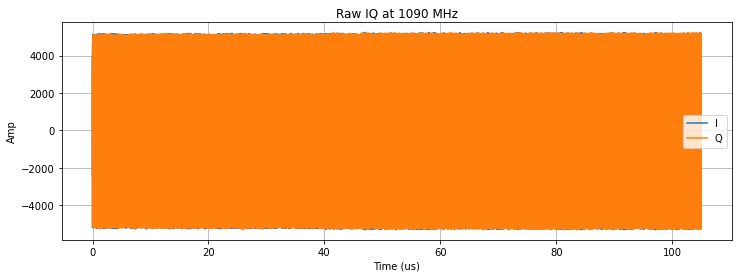

In [31]:
import matplotlib.pyplot as plt
t = np.arange(len(iq_data)) / 128e6 * 1e6

plt.figure(figsize=(12,4))
plt.plot(t, np.real(iq_data), label='I')
plt.plot(t, np.imag(iq_data), label='Q')
plt.xlabel('Time (us)')
plt.ylabel('Amp')
plt.title('Raw IQ at 1090 MHz')
plt.legend()
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1481
-49.8952380952381
70.8977516590704
6720
(-39.38489583333334-39.01889880952381j)

Bins around peak: 
 bin 1476: 45.09 dB
 bin 1477: 50.69 dB
 bin 1478: 47.40 dB
 bin 1479: 57.97 dB
 bin 1480: 60.83 dB
 bin 1481: 70.90 dB
 bin 1482: 66.51 dB
 bin 1483: 63.97 dB
 bin 1484: 59.38 dB
 bin 1485: 50.87 dB
(13440,)
5342.572882048498
complex128
FFT MAX VALUE:  70.89775165907014


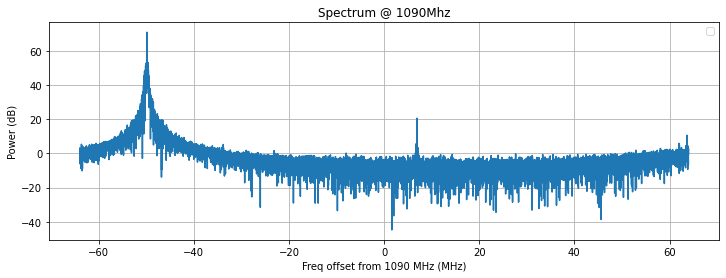

In [32]:
# I can't emphasises enough how scuffed this is

#iq_clean = iq_data - np.mean(iq_data)
iq_clean = iq_data
N = len(iq_clean)
fftRaw = np.fft.fft(iq_clean) # Consider iq_data / N to normalise 
fft_norm = np.fft.fftshift(fftRaw) / N
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/128e6)) / 1e6 # MHz offset from 1090MHz

power = 20*np.log10(np.abs(fft_norm) + 1e-10)
peak_bin = np.argmax(power)
print(peak_bin)
print(freqs[peak_bin])
print(power[peak_bin])
print(N//2)
print(fft_norm[N//2])
print("\nBins around peak: ")
for i in range(peak_bin-5, peak_bin+5):
    print(f" bin {i}: {power[i]:.2f} dB")

print(iq_data.shape) #debug
print(np.max(np.abs(iq_data))) #debug
print(iq_data.dtype) #debug
print("FFT MAX VALUE: ", 20*np.log10(np.max(np.abs(fft_norm))))


centre_bin = N//2
fft_norm[centre_bin] = (fft_norm[centre_bin - 1] + fft_norm[centre_bin + 1]) / 2

plt.figure(figsize=(12,4))
plt.plot(freqs, 20*np.log10(np.abs(fft_norm) + 1e-10))

plt.xlabel('Freq offset from 1090 MHz (MHz)')
plt.ylabel('Power (dB)')
plt.title('Spectrum @ 1090Mhz')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
qpsk.qpsk_tx.qpsk_tx.enable = 0